In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from pathlib import Path

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = '/content/drive/MyDrive/DatasetWeather'

classes = ('cloudy', 'rain', 'shine', 'sunrise')
print(f"Clases: {classes}")
print(f"Número de clases: {len(classes)}")

Mounted at /content/drive
Clases: ('cloudy', 'rain', 'shine', 'sunrise')
Número de clases: 4


       EXPLORACIÓN DEL DATASET DE CLIMA

📁 Estructura del dataset:
  📂 Cloudy      :  300 imágenes  ██████████████████████████████
  📂 Rain        :  215 imágenes  █████████████████████
  📂 Shine       :  253 imágenes  █████████████████████████
  📂 Sunrise     :  357 imágenes  ███████████████████████████████████

  Total imágenes: 1125
  Total clases:   4

📐 Resoluciones encontradas en el dataset:
  (275, 183)          : 6 imágenes
  (300, 168)          : 5 imágenes
  (259, 194)          : 3 imágenes
  (480, 360)          : 3 imágenes
  (284, 177)          : 3 imágenes
  (1024, 768)         : 2 imágenes
  (852, 480)          : 2 imágenes
  (271, 186)          : 1 imágenes
  (288, 175)          : 1 imágenes
  (800, 377)          : 1 imágenes

🖼️  Formatos de archivo:
  .jpg       : 1122 archivos
  .jpeg      : 3 archivos

🔍 Mostrando 1 imagen de muestra por clase:


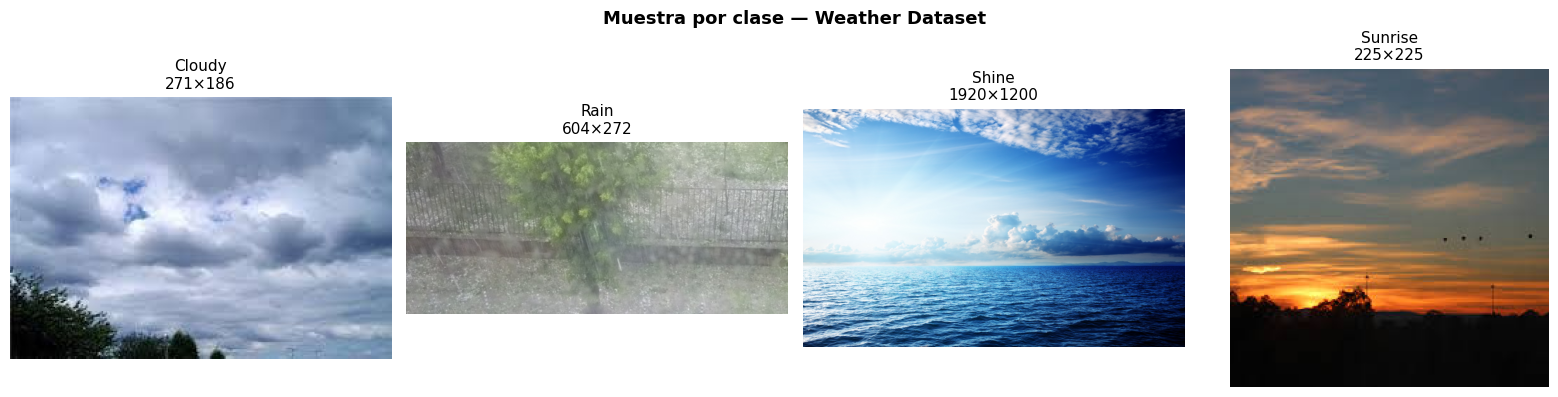


✅ Exploración completada — sin ninguna transformación aplicada


In [ ]:

import os
from PIL import Image

print("=" * 50)
print("       EXPLORACIÓN DEL DATASET DE CLIMA")
print("=" * 50)

# --- Clases y cantidad de imágenes por clase ---
print("\n📁 Estructura del dataset:")
total_imgs = 0
class_info = {}

for class_name in sorted(os.listdir(DATASET_PATH)):
    class_path = os.path.join(DATASET_PATH, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        count  = len(images)
        total_imgs += count
        class_info[class_name] = {'count': count, 'images': images}
        barra = '█' * (count // 10)
        print(f"  📂 {class_name:12s}: {count:4d} imágenes  {barra}")

print(f"\n  Total imágenes: {total_imgs}")
print(f"  Total clases:   {len(class_info)}")

# --- Resoluciones de las imágenes ---
print("\n📐 Resoluciones encontradas en el dataset:")
resoluciones = {}

for class_name, info in class_info.items():
    for img_name in info['images'][:20]:  # muestra de 20 por clase
        img_path = os.path.join(DATASET_PATH, class_name, img_name)
        try:
            with Image.open(img_path) as img:
                res = img.size  # (ancho, alto)
                resoluciones[res] = resoluciones.get(res, 0) + 1
        except:
            pass

for res, count in sorted(resoluciones.items(), key=lambda x: -x[1])[:10]:
    print(f"  {str(res):20s}: {count} imágenes")

# --- Formatos de archivo ---
print("\n🖼️  Formatos de archivo:")
formatos = {}
for class_name, info in class_info.items():
    for img_name in info['images']:
        ext = img_name.split('.')[-1].lower()
        formatos[ext] = formatos.get(ext, 0) + 1

for fmt, count in sorted(formatos.items(), key=lambda x: -x[1]):
    print(f"  .{fmt:10s}: {count} archivos")

# --- Muestra de imágenes por clase ---
print("\n🔍 Mostrando 1 imagen de muestra por clase:")
fig, axes = plt.subplots(1, len(class_info), figsize=(16, 4))

for ax, (class_name, info) in zip(axes, class_info.items()):
    sample_path = os.path.join(DATASET_PATH, class_name, info['images'][0])
    try:
        img_sample = Image.open(sample_path).convert('RGB')
        ax.imshow(img_sample)
        ax.set_title(f"{class_name}\n{img_sample.size[0]}×{img_sample.size[1]}", fontsize=11)
        ax.axis('off')
    except:
        ax.set_title(f"{class_name}\n(error)")
        ax.axis('off')

plt.suptitle("Muestra por clase — Weather Dataset", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ Exploración completada — sin ninguna transformación aplicada")
print("=" * 50)

In [ ]:
import numpy as np
from torchvision.datasets import ImageFolder

# Transformación mínima: redimensionar a 150x150 (requisito del instructor)
transform_base = transforms.Compose([
    transforms.Resize((168, 168)),
    transforms.ToTensor()
])

In [ ]:
# Cargar dataset completo
full_dataset = ImageFolder(root=DATASET_PATH, transform=transform_base)

In [ ]:
# Convertir a numpy para mantener la misma estructura del código fuente
print("Cargando imágenes")
train_imgs   = np.array([np.array(img.permute(1,2,0)) for img, _ in full_dataset])
train_labels = np.array([label for _, label in full_dataset])

print(f"Shape imágenes: {train_imgs.shape}")   # (N, 150, 150, 3)
print(f"Shape etiquetas: {train_labels.shape}") # (N,)
print(f"Total imágenes: {len(train_imgs)}")

Cargando imágenes
Shape imágenes: (1125, 168, 168, 3)
Shape etiquetas: (1125,)
Total imágenes: 1125


In [ ]:
print("Tipo imágenes:", train_imgs.dtype)
print("Tipo etiquetas:", train_labels.dtype)

Tipo imágenes: float32
Tipo etiquetas: int64


In [ ]:
max_value = train_imgs.max(axis=(0, 1, 2))
min_value = train_imgs.min(axis=(0, 1, 2))
print(f"\nMáx por canal RGB: {max_value}")
print(f"Mín por canal RGB: {min_value}")


Máx por canal RGB: [1. 1. 1.]
Mín por canal RGB: [0. 0. 0.]


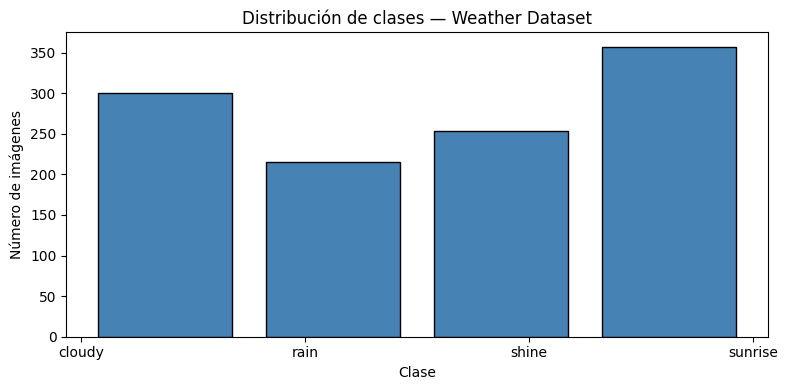

In [ ]:
import matplotlib.pyplot as plt

# Distribución de clases
plt.figure(figsize=(8, 4))
plt.hist(train_labels, bins=len(classes),
         color='steelblue', edgecolor='black', rwidth=0.8)
plt.xticks(ticks=range(len(classes)), labels=classes)
plt.title('Distribución de clases — Weather Dataset')
plt.xlabel('Clase')
plt.ylabel('Número de imágenes')
plt.tight_layout()
plt.show()

In [ ]:
print("\n📊 Imágenes por clase:")
for i, cls in enumerate(classes):
    count = (train_labels == i).sum()
    barra = '█' * (count // 10)
    print(f"  {cls:10s}: {count:4d} imágenes  {barra}")


📊 Imágenes por clase:
  cloudy    :  300 imágenes  ██████████████████████████████
  rain      :  215 imágenes  █████████████████████
  shine     :  253 imágenes  █████████████████████████
  sunrise   :  357 imágenes  ███████████████████████████████████


# CELDA 4 — Visualizar una imagen aleatoria del dataset

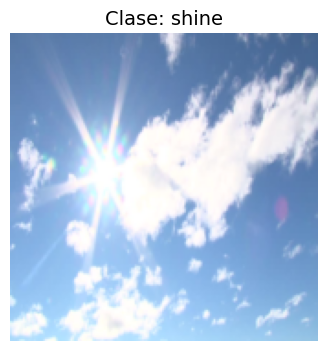

In [ ]:
import random
import matplotlib.pyplot as plt

ix = random.randint(0, len(train_imgs) - 1)
img, label = train_imgs[ix], train_labels[ix]

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(f"Clase: {classes[label]}", fontsize=14)
plt.axis('off')
plt.show()

# CELDA 5 — Filtro horizontal (detecta líneas horizontales)

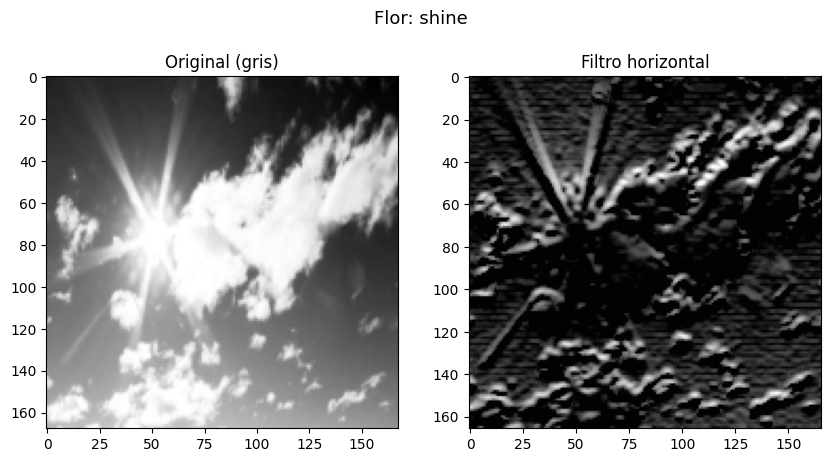

In [ ]:
from skimage import color, exposure
import scipy.signal

img_gray = color.rgb2gray(img)  # Convertir a escala de grises

kernel = np.array([[1,  1,  1],
                   [0,  0,  0],
                   [-1,-1, -1]])

edges = scipy.signal.convolve2d(img_gray, kernel, 'valid')
edges = exposure.equalize_adapthist(edges / np.max(np.abs(edges)), clip_limit=0.03)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(img_gray, cmap=plt.cm.gray)
ax1.set_title("Original (gris)")
ax2.imshow(edges, cmap=plt.cm.gray)
ax2.set_title("Filtro horizontal")
plt.suptitle(f"Flor: {classes[label]}", fontsize=13)
plt.show()

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random
import matplotlib.pyplot as plt
from tqdm import tqdm


device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


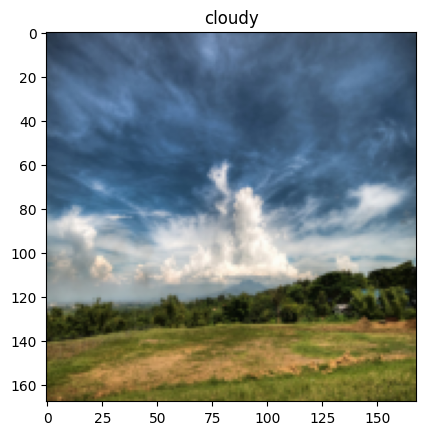

In [ ]:
from torchvision.datasets import ImageFolder

transform_base = transforms.Compose([
    transforms.Resize((168, 168)),
    transforms.ToTensor()
])

full_dataset = ImageFolder(root=DATASET_PATH, transform=transform_base)

train_imgs   = np.array([np.array(img.permute(1,2,0)) for img, _ in full_dataset])
train_labels = np.array([label for _, label in full_dataset])

ix = random.randint(0, len(train_imgs) - 1)
img, label = train_imgs[ix], train_labels[ix]

plt.imshow(img)
plt.title(classes[label])
plt.show()

In [ ]:
img_tensor = torch.from_numpy(img / 255.).unsqueeze(0)
img_tensor = img_tensor.permute(0, 3, 1, 2).float()

print("Shape tensor:", img_tensor.shape, "| dtype:", img_tensor.dtype)

Shape tensor: torch.Size([1, 3, 168, 168]) | dtype: torch.float32


In [ ]:
conv = torch.nn.Conv2d(in_channels=3, out_channels=10, kernel_size=5)
output = conv(img_tensor)

print("Salida conv (N, #filtros, H', W'):", output.shape)

Salida conv (N, #filtros, H', W'): torch.Size([1, 10, 164, 164])


In [ ]:
conv = torch.nn.Conv2d(in_channels=3, out_channels=10,
                       kernel_size=5, padding=0, stride=1)
output = conv(img_tensor)
print("Con stride=2:", output.shape)

Con stride=2: torch.Size([1, 10, 164, 164])


In [ ]:
conv1 = torch.nn.Conv2d(in_channels=10, out_channels=32,
                        kernel_size=3, padding=1, stride=1)
output2 = conv1(output)
print("Segunda capa:", output2.shape)

Segunda capa: torch.Size([1, 32, 164, 164])


Tras MaxPool: torch.Size([1, 3, 168, 168])


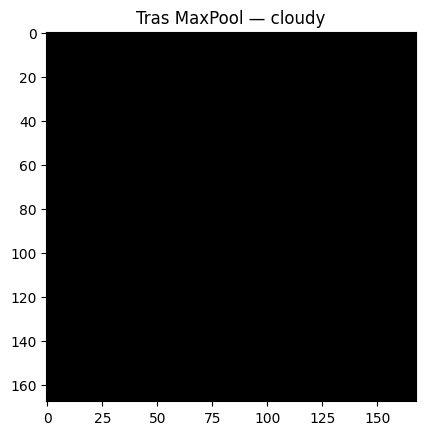

In [ ]:
pool = torch.nn.MaxPool2d(3, padding=1, stride=1)
img_tensor = torch.from_numpy(img / 255.).unsqueeze(0).permute(0,3,1,2).float()
output = pool(img_tensor)
print("Tras MaxPool:", output.shape)
# → torch.Size([1, 3, 75, 75])

plt.imshow(output.squeeze(0).permute(1,2,0).detach().numpy())
plt.title(f"Tras MaxPool — {classes[label]}")
plt.show()

In [ ]:
transform_train = transforms.Compose([
    transforms.Resize((168, 168)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

transform_test = transforms.Compose([
    transforms.Resize((168, 168)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

In [ ]:
full_dataset_norm = ImageFolder(root=DATASET_PATH, transform=transform_train)
n_total  = len(full_dataset_norm)
n_train  = int(0.8 * n_total)
n_test   = n_total - n_train

train_set, test_set = torch.utils.data.random_split(
    full_dataset_norm, [n_train, n_test]
)

In [ ]:
test_set.dataset.transform = transform_test

dataloader = {
    'train': torch.utils.data.DataLoader(
        train_set, batch_size=64, shuffle=True, pin_memory=True),
    'test': torch.utils.data.DataLoader(
        test_set, batch_size=64, shuffle=False, pin_memory=True)
}

print(f"Train: {n_train} imágenes | Test: {n_test} imágenes")

Train: 900 imágenes | Test: 225 imágenes


In [ ]:
def block(c_in, c_out, k=5, p=0, s=1, pk=2, ps=2):
    return torch.nn.Sequential(
        torch.nn.Conv2d(c_in, c_out, k, padding=p, stride=s),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(pk, stride=ps)
    )

def block2(c_in, c_out):
    return torch.nn.Sequential(
        torch.nn.Linear(c_in, c_out),
        torch.nn.ReLU()
    )

In [ ]:
class CNN(torch.nn.Module):
    def __init__(self, n_channels=3, n_outputs=4):  # RGB=3, clases=4
        super().__init__()
        self.conv1 = block(n_channels, 32)
        self.conv2 = block(32, 64)
        self.fc    = torch.nn.Linear(64 * 39 * 39, n_outputs)

    def forward(self, x):
        print("Dimensiones:")
        print("Entrada:", x.shape)
        x = self.conv1(x)
        print("conv1:", x.shape)
        x = self.conv2(x)
        print("conv2:", x.shape)
        x = x.view(x.shape[0], -1)
        print("pre fc:", x.shape)
        x = self.fc(x)
        print("Salida:", x.shape)
        return x

In [ ]:
class CNN(torch.nn.Module):
    def __init__(self, n_channels=3, n_outputs=4):
        super().__init__()
        self.conv1 = block(n_channels, 32)
        self.conv2 = block(32, 64)
        self.fc    = torch.nn.Linear(64 * 39 * 39, n_outputs)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.view(x.shape[0], -1)
        x = self.fc(x)
        return x

In [ ]:
def fit(model, dataloader, epochs=5):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.CrossEntropyLoss()
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss, train_acc = [], []
        bar = tqdm(dataloader['train'])
        for batch in bar:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
            acc = (y == torch.argmax(y_hat, axis=1)).sum().item() / len(y)
            train_acc.append(acc)
            bar.set_description(f"loss {np.mean(train_loss):.5f} acc {np.mean(train_acc):.5f}")
        val_loss, val_acc = [], []
        model.eval()
        bar = tqdm(dataloader['test'])
        with torch.no_grad():
            for batch in bar:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss = criterion(y_hat, y)
                val_loss.append(loss.item())
                acc = (y == torch.argmax(y_hat, axis=1)).sum().item() / len(y)
                val_acc.append(acc)
                bar.set_description(f"val_loss {np.mean(val_loss):.5f} val_acc {np.mean(val_acc):.5f}")
        print(f"Epoch {epoch}/{epochs} loss {np.mean(train_loss):.5f} val_loss {np.mean(val_loss):.5f} "
              f"acc {np.mean(train_acc):.5f} val_acc {np.mean(val_acc):.5f}")

In [ ]:
model = CNN(n_channels=3, n_outputs=4)
fit(model, dataloader, epochs=10)

  0%|          | 0/15 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
val_loss 0.63744 val_acc 0.75556: 100%|██████████| 4/4 [00:09<00:00,  2.28s/it]


Epoch 1/10 loss 1.35042 val_loss 0.63744 acc 0.52500 val_acc 0.75556


val_loss 0.43683 val_acc 0.84126: 100%|██████████| 4/4 [00:08<00:00,  2.07s/it]


Epoch 2/10 loss 0.64654 val_loss 0.43683 acc 0.74687 val_acc 0.84126


val_loss 0.37188 val_acc 0.87595: 100%|██████████| 4/4 [00:08<00:00,  2.09s/it]


...

Epoch 8/10 loss 0.15581 val_loss 0.29838 acc 0.94271 val_acc 0.91844


val_loss 0.31763 val_acc 0.88743: 100%|██████████| 4/4 [00:09<00:00,  2.38s/it]


Epoch 9/10 loss 0.17260 val_loss 0.31763 acc 0.93229 val_acc 0.88743


val_loss 0.28009 val_acc 0.89915: 100%|██████████| 4/4 [00:07<00:00,  1.94s/it]

Epoch 10/10 loss 0.14337 val_loss 0.28009 acc 0.95625 val_acc 0.89915


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


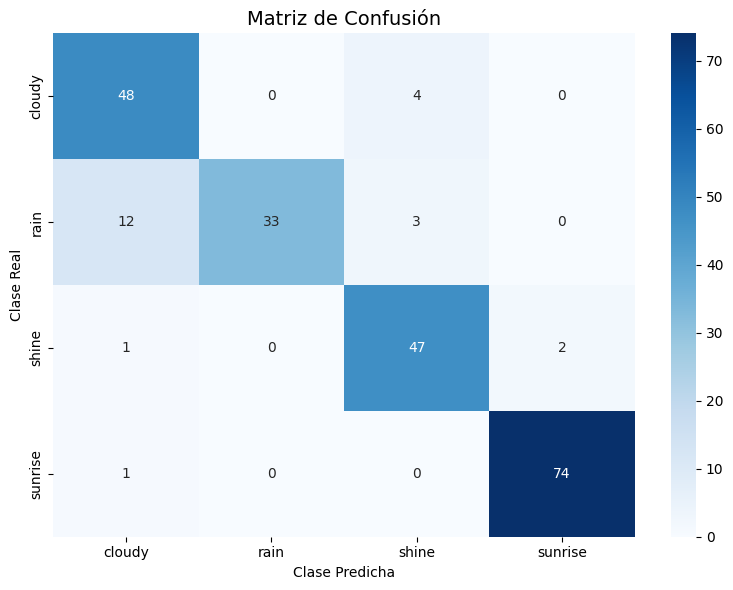


📊 Reporte de clasificación:
              precision    recall  f1-score   support

      cloudy       0.77      0.92      0.84        52
        rain       1.00      0.69      0.81        48
       shine       0.87      0.94      0.90        50
     sunrise       0.97      0.99      0.98        75

    accuracy                           0.90       225
   macro avg       0.90      0.88      0.89       225
weighted avg       0.91      0.90      0.90       225

✅ Accuracy global: 89.78%


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def evaluate_model(model, dataloader):
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for X, y in dataloader['test']:
            X, y   = X.to(device), y.to(device)
            y_hat  = model(X)
            preds  = torch.argmax(y_hat, axis=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    # --- Matriz de confusión ---
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes,
                yticklabels=classes)
    plt.title('Matriz de Confusión', fontsize=14)
    plt.ylabel('Clase Real')
    plt.xlabel('Clase Predicha')
    plt.tight_layout()
    plt.show()

    # --- Reporte de precisión por clase ---
    print("\n📊 Reporte de clasificación:")
    print(classification_report(all_labels, all_preds,
                                target_names=classes))

    # --- Accuracy global ---
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"✅ Accuracy global: {acc * 100:.2f}%")


evaluate_model(model, dataloader)

In [ ]:
from PIL import Image

def predict_image(model, image_path):
    model.eval()

    # Cargar y transformar la imagen
    transform_pred = transforms.Compose([
        transforms.Resize((168, 168)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5],
                             std=[0.5, 0.5, 0.5])
    ])

    img_pil   = Image.open(image_path).convert('RGB')
    img_tensor = transform_pred(img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        output      = model(img_tensor)
        probs       = torch.nn.functional.softmax(output, dim=1)[0]
        pred_idx    = torch.argmax(probs).item()
        pred_class  = classes[pred_idx]
        confidence  = probs[pred_idx].item() * 100

    # --- Mostrar imagen con resultado ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.imshow(img_pil)
    color_title = 'green' if confidence > 70 else 'orange'
    ax1.set_title(f"Predicción: {pred_class}\nConfianza: {confidence:.1f}%",
                  fontsize=13, color=color_title, fontweight='bold')
    ax1.axis('off')

    # --- Barra de probabilidades por clase ---
    colores = ['#2ecc71' if i == pred_idx else '#3498db' for i in range(len(classes))]
    bars = ax2.bar(classes, probs.cpu().numpy() * 100, color=colores)
    ax2.set_ylabel('Probabilidad (%)')
    ax2.set_title('Probabilidad por clase')
    ax2.set_ylim(0, 100)

    for bar, prob in zip(bars, probs.cpu().numpy()):
        ax2.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{prob*100:.1f}%',
                 ha='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    print(f"\n🌤️  Imagen clasificada como: {pred_class.upper()}")
    print(f"📈 Confianza: {confidence:.1f}%")
    print("\n📊 Probabilidades por clase:")
    for i, (cls, prob) in enumerate(zip(classes, probs.cpu().numpy())):
        barra = '█' * int(prob * 30)
        print(f"  {'→' if i == pred_idx else ' '} {cls:10s} {barra} {prob*100:.1f}%")


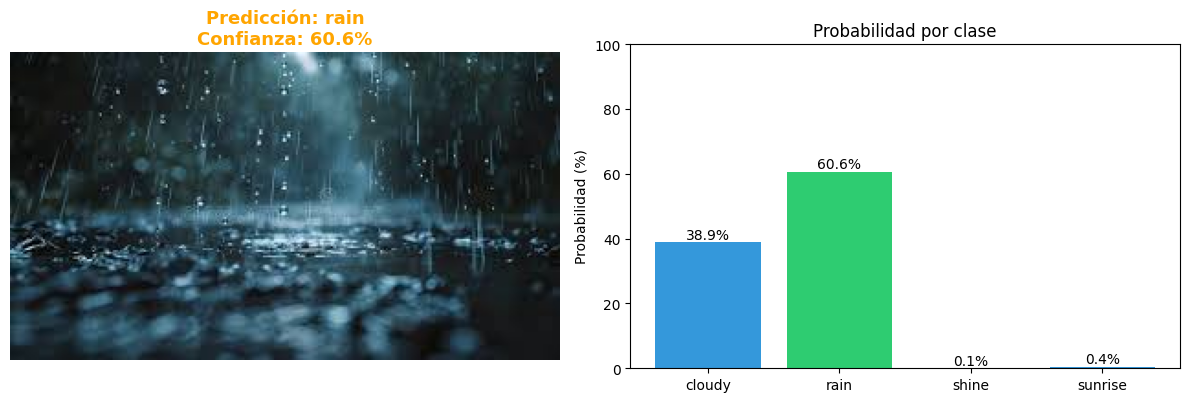


🌤️  Imagen clasificada como: RAIN
📈 Confianza: 60.6%

📊 Probabilidades por clase:
    cloudy     ███████████ 38.9%
  → rain       ██████████████████ 60.6%
    shine       0.1%
    sunrise     0.4%


In [ ]:
IMAGE_PATH = '/content/drive/MyDrive/lluviaPrueba.jpg'
predict_image(model, IMAGE_PATH)

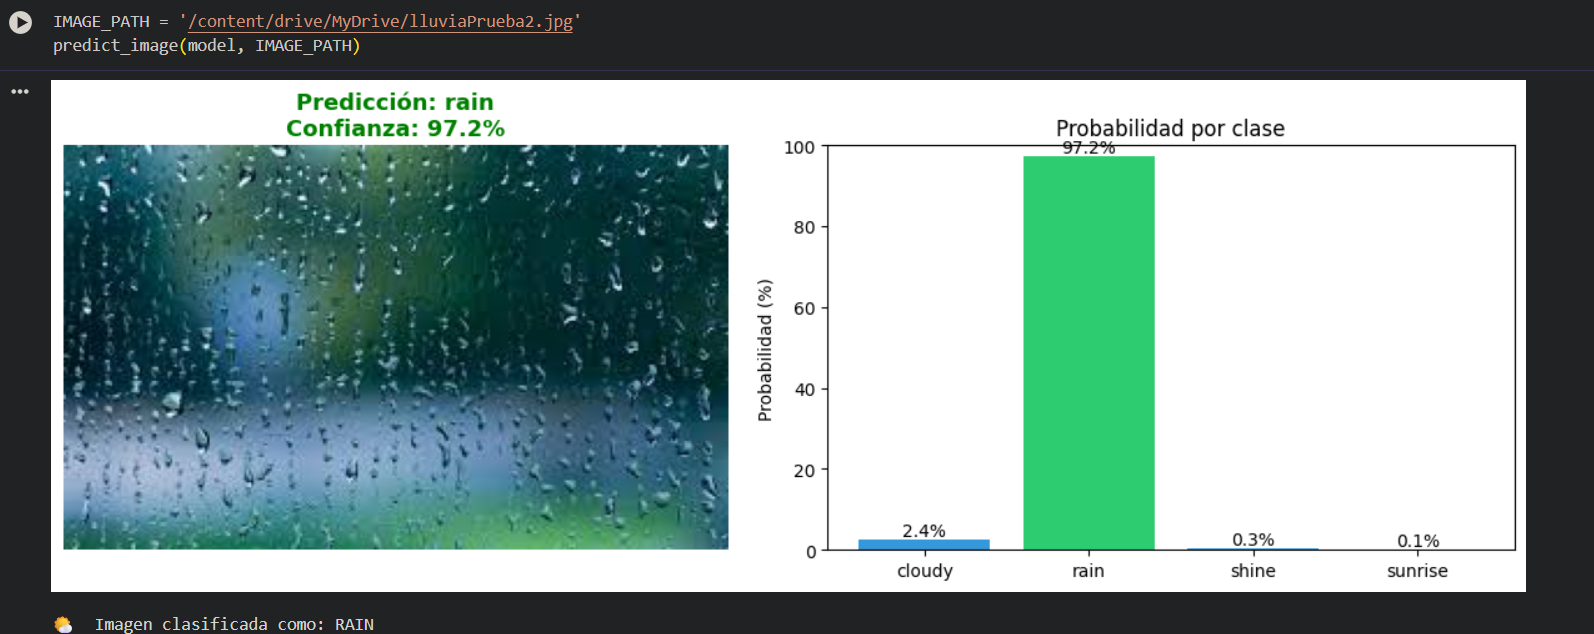

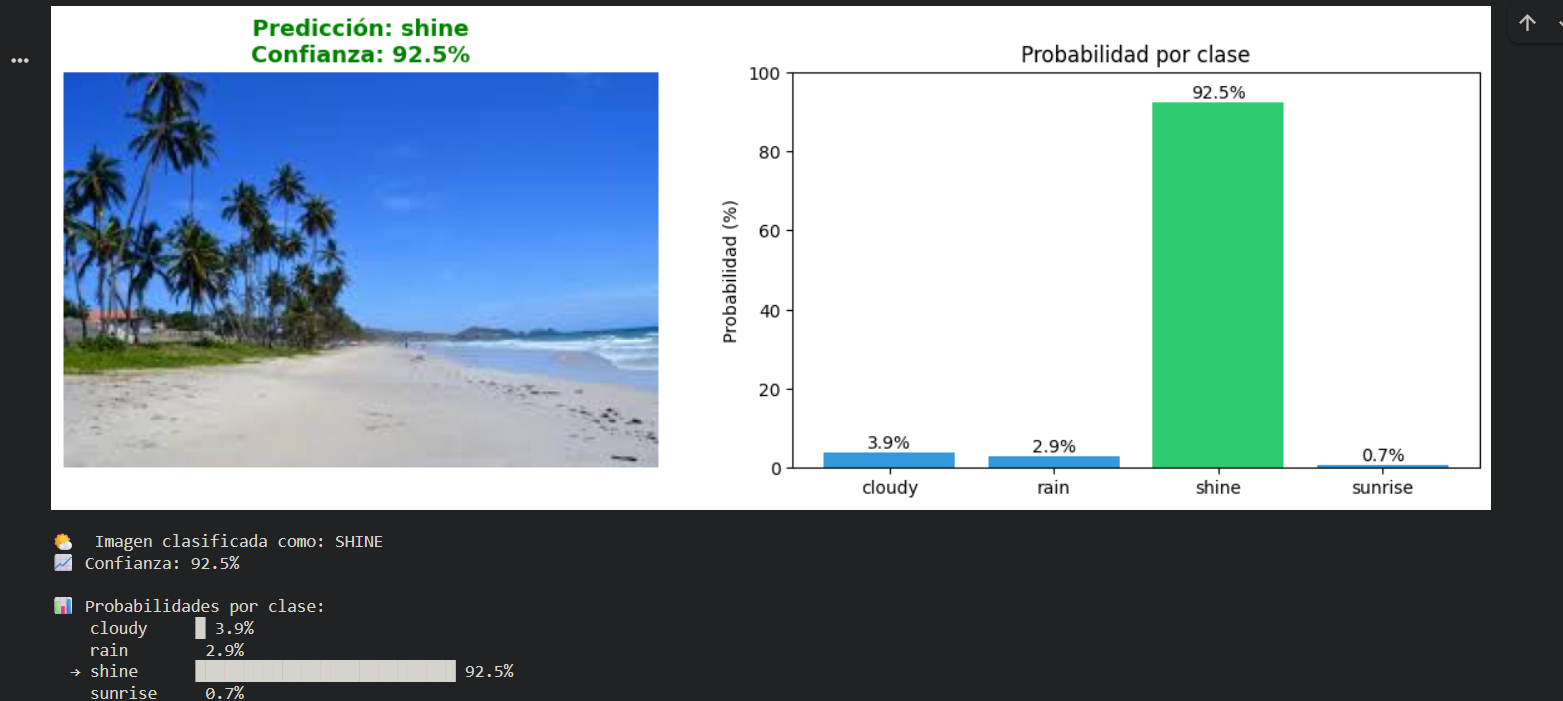

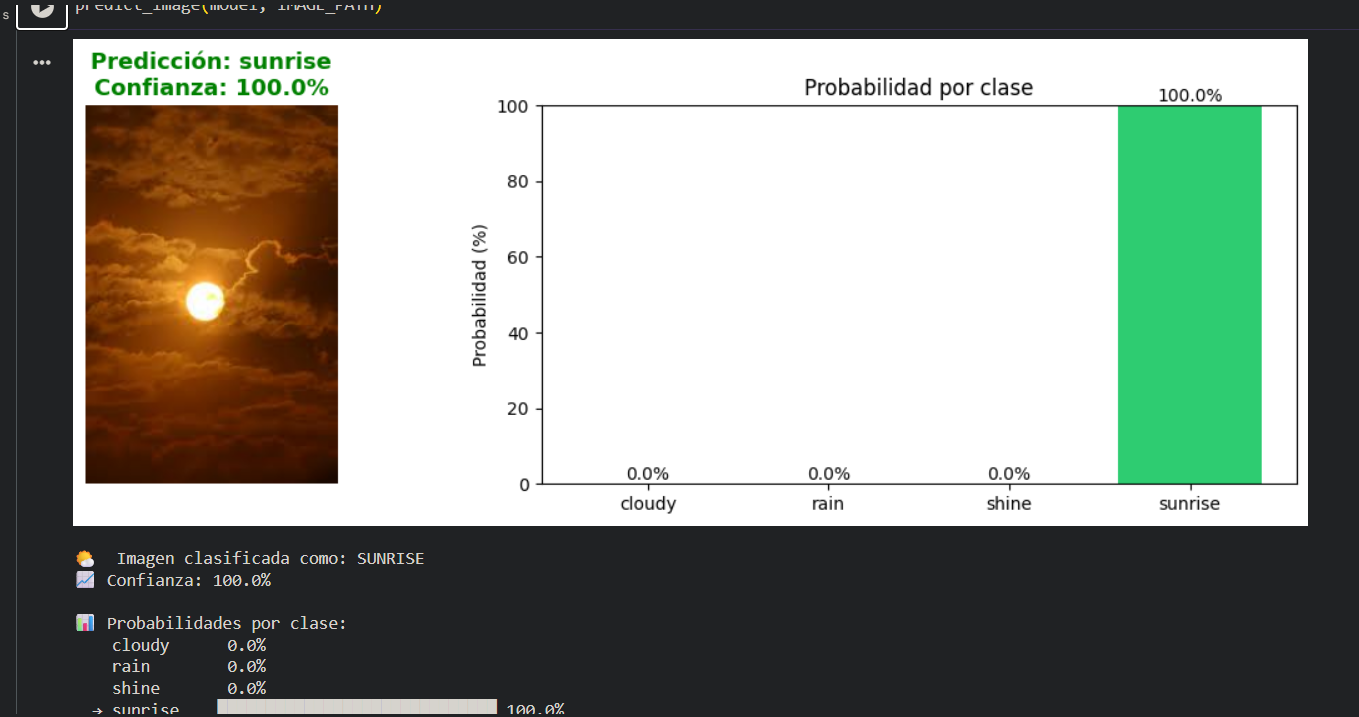

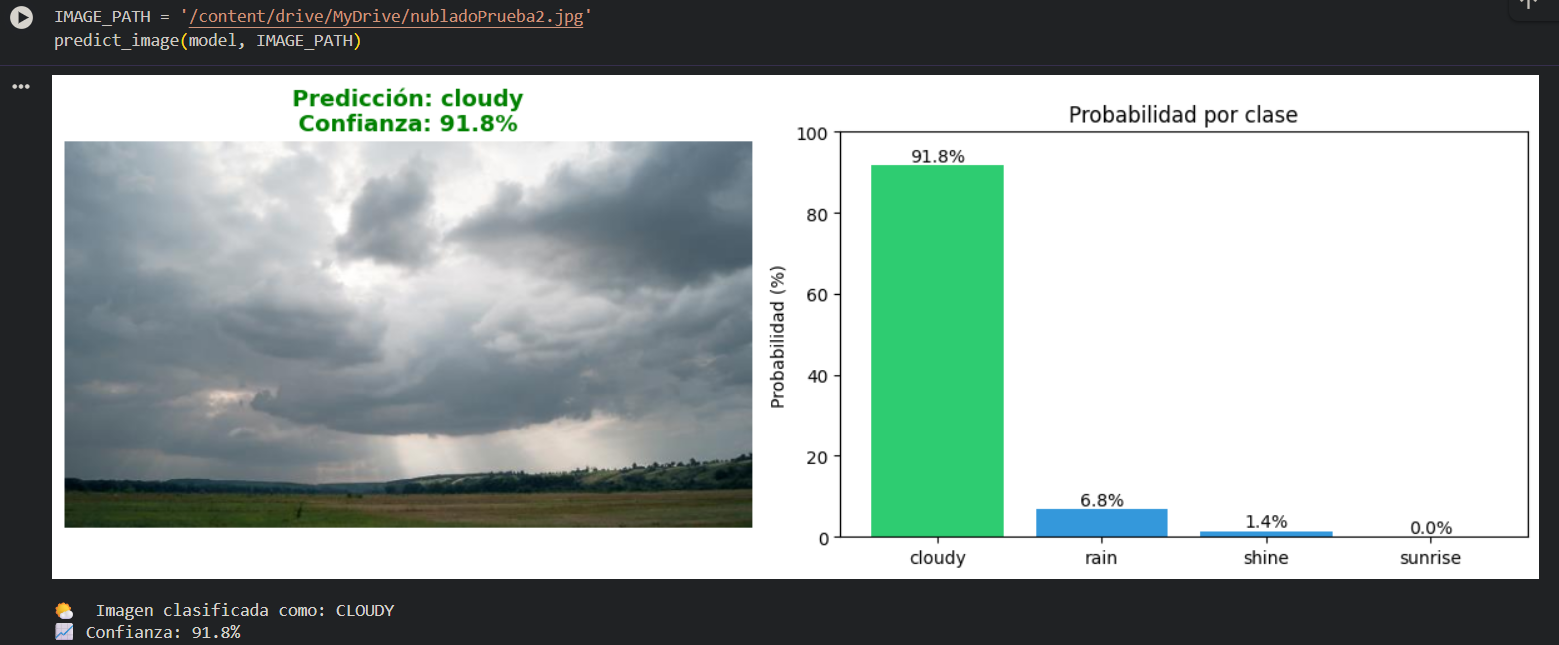